In [31]:
import mlflow
import mlflow.sklearn

import pandas as pd

from pathlib import Path
import sys

import mlflow
from pathlib import Path

from pathlib import Path
import mlflow

PROJECT_ROOT = Path.cwd().parent

mlflow.set_tracking_uri(
    f"sqlite:///{PROJECT_ROOT}/mlflow.db"
)

print("Tracking URI:", mlflow.get_tracking_uri())

PROJECT_ROOT = Path.cwd().parent

mlflow.set_tracking_uri(
    f"sqlite:///{PROJECT_ROOT}/mlflow.db"
)

print(mlflow.get_tracking_uri())

print("MLflow Version:", mlflow.__version__)

Tracking URI: sqlite:///d:\DIVY\CODING\PURECODING\AI-ML\Week9\Devops\JobClarity/mlflow.db
sqlite:///d:\DIVY\CODING\PURECODING\AI-ML\Week9\Devops\JobClarity/mlflow.db
MLflow Version: 3.15.0


In [16]:
PROJECT_ROOT = Path.cwd().parent

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print(PROJECT_ROOT)

d:\DIVY\CODING\PURECODING\AI-ML\Week9\Devops\JobClarity


In [17]:
from src.models.model_loader import (
    load_model,
    load_vectorizer
)

model = load_model()
vectorizer = load_vectorizer()

print(type(model))
print(type(vectorizer))

<class 'xgboost.sklearn.XGBClassifier'>
<class 'sklearn.feature_extraction.text.TfidfVectorizer'>


In [18]:
DATA_PATH = "../data/processed/cleaned_jobs.csv"

df = pd.read_csv(DATA_PATH)

print(df.shape)

(17880, 17)


In [19]:
X = vectorizer.transform(
    df["combined_text"]
)

y = df["fraudulent"]

print(X.shape)

(17880, 10000)


In [20]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(X_train.shape)
print(X_test.shape)

(14304, 10000)
(3576, 10000)


In [21]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score
)

pred = model.predict(X_test)

prob = model.predict_proba(X_test)[:,1]

accuracy = accuracy_score(y_test,pred)
precision = precision_score(y_test,pred)
recall = recall_score(y_test,pred)
f1 = f1_score(y_test,pred)
roc_auc = roc_auc_score(y_test,prob)

print("Accuracy :",accuracy)
print("Precision:",precision)
print("Recall   :",recall)
print("F1 Score :",f1)
print("ROC AUC  :",roc_auc)

Accuracy : 0.9854586129753915
Precision: 0.9618320610687023
Recall   : 0.7283236994219653
F1 Score : 0.8289473684210527
ROC AUC  : 0.9835337402054292


In [22]:
mlflow.set_experiment("JobClarity")

<Experiment: artifact_location='file:///d:/DIVY/CODING/PURECODING/AI-ML/Week9/Devops/JobClarity/notebooks/mlruns/1', creation_time=1785498440304, effective_trace_archival_retention=None, experiment_id='1', last_update_time=1785498440304, lifecycle_stage='active', name='JobClarity', tags={}, trace_location=None, workspace='default'>

In [24]:
with mlflow.start_run(run_name="XGBoost_Tuned"):

    # Parameters
    mlflow.log_param("model","XGBoost")
    mlflow.log_param("vectorizer","TF-IDF")
    mlflow.log_param("max_features",10000)
    mlflow.log_param("ngram_range","(1,2)")
    mlflow.log_param("dataset_size",len(df))

    # Metrics
    mlflow.log_metric("accuracy",accuracy)
    mlflow.log_metric("precision",precision)
    mlflow.log_metric("recall",recall)
    mlflow.log_metric("f1_score",f1)
    mlflow.log_metric("roc_auc",roc_auc)

    import mlflow.xgboost

    mlflow.xgboost.log_model(
        xgb_model=model,
        artifact_path="model"
    )

    print("✅ Experiment Logged Successfully")

2026/07/31 17:28:29 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


✅ Experiment Logged Successfully


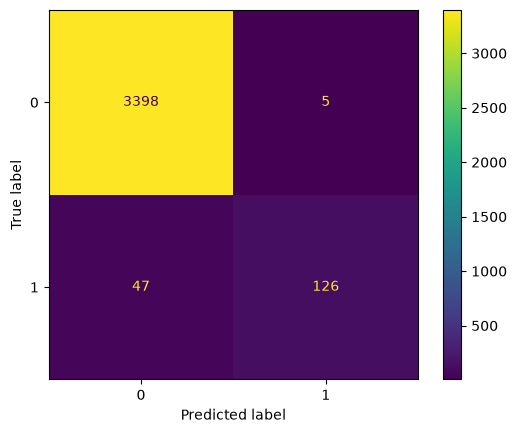

In [25]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_test, pred)

disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()

plt.savefig(
    "../artifacts/confusion_matrix.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

In [26]:
with mlflow.start_run(run_name="Artifacts"):

    mlflow.log_artifact("../artifacts/confusion_matrix.png")
    mlflow.log_artifact("../artifacts/feature_importance.csv")
    mlflow.log_artifact("../artifacts/model_comparison.csv")

    print("✅ Artifacts Logged")

✅ Artifacts Logged


In [32]:
experiment_name = "JobClarity"

mlflow.set_experiment(experiment_name)

experiment = mlflow.get_experiment_by_name(experiment_name)

print(experiment.experiment_id)

2026/07/31 17:40:40 INFO mlflow.tracking.fluent: Experiment with name 'JobClarity' does not exist. Creating a new experiment.


1


In [33]:
with mlflow.start_run(run_name="XGBoost_Tuned_Production"):
    print("Run Started")

Run Started


In [34]:
import mlflow.xgboost

with mlflow.start_run(run_name="XGBoost_Tuned_Production"):

    # -------------------------
    # Log Hyperparameters
    # -------------------------
    params = model.get_params()

    for key, value in params.items():
        mlflow.log_param(key, value)

    mlflow.log_param("vectorizer", "TF-IDF")
    mlflow.log_param("max_features", 10000)
    mlflow.log_param("ngram_range", "(1,2)")

    # -------------------------
    # Log Metrics
    # -------------------------
    mlflow.log_metric("accuracy", accuracy)
    mlflow.log_metric("precision", precision)
    mlflow.log_metric("recall", recall)
    mlflow.log_metric("f1_score", f1)
    mlflow.log_metric("roc_auc", roc_auc)

    # -------------------------
    # Log Tags
    # -------------------------
    mlflow.set_tag("project", "JobClarity")
    mlflow.set_tag("author", "Divya Saxena")
    mlflow.set_tag("model_type", "XGBoost")
    mlflow.set_tag("stage", "Production")

    # -------------------------
    # Log Model
    # -------------------------
    model_info = mlflow.xgboost.log_model(
        xgb_model=model,
        name="model"
    )

    # -------------------------
    # Log Artifacts
    # -------------------------
    mlflow.log_artifact("../artifacts/confusion_matrix.png")
    mlflow.log_artifact("../artifacts/feature_importance.csv")
    mlflow.log_artifact("../artifacts/model_comparison.csv")

    print("✅ Production Experiment Logged")

✅ Production Experiment Logged


In [35]:
from mlflow import MlflowClient

client = MlflowClient()

result = mlflow.register_model(
    model_uri=model_info.model_uri,
    name="JobClarity-XGBoost"
)

print(result)

<ModelVersion: aliases=[], creation_timestamp=1785499962650, current_stage='None', deployment_job_state=None, description=None, last_updated_timestamp=1785499962650, metrics=None, model_id=None, name='JobClarity-XGBoost', params=None, run_id='572a229c735048e99fa9314bec7ab811', run_link=None, source='models:/m-028d41425fc94c8a97fcaeb6a5c09f4a', status='READY', status_message=None, tags={}, user_id=None, version=1, workspace='default'>


Successfully registered model 'JobClarity-XGBoost'.
Created version '1' of model 'JobClarity-XGBoost'.


In [36]:
client = MlflowClient()

for model in client.search_registered_models():
    print("Model:", model.name)

Model: JobClarity-XGBoost


In [37]:
versions = client.search_model_versions(
    "name='JobClarity-XGBoost'"
)

for version in versions:
    print("Version :", version.version)
    print("Stage   :", version.current_stage)

Version : 1
Stage   : None


In [38]:
client.update_registered_model(
    name="JobClarity-XGBoost",
    description="""
JobClarity Production Model

Algorithm : XGBoost
Vectorizer : TF-IDF
Hyperparameter Tuning : Optuna
Fraud Detection System

Accuracy : 98.55%
Precision : 96.18%
Recall : 72.83%
F1 Score : 82.89%
ROC-AUC : 98.35%
"""
)

print("✅ Description Added")

✅ Description Added
